Importing the Required Libraries

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from locale import normalize

Loading the Dataset and doing the necessary 

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Identifyting the missing Values

In [5]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


Identifying and counting hte missing values per column

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
(df.isnull().sum() / len(df)) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

Replace Missing Values in the Age column with the mean / Median of the age based on the analysis

In [8]:
df['Age'].mean()

29.69911764705882

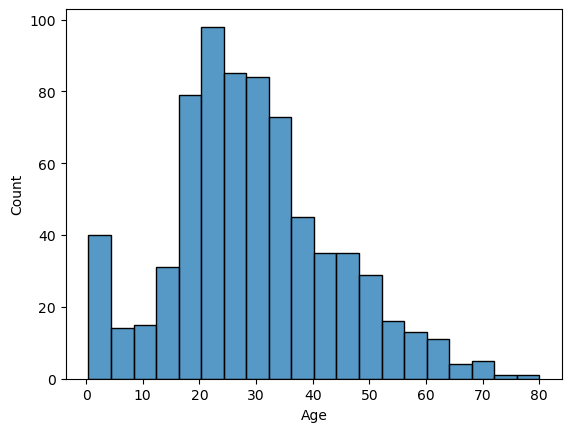

In [9]:
sns.histplot(x = 'Age', data = df)
plt.show()

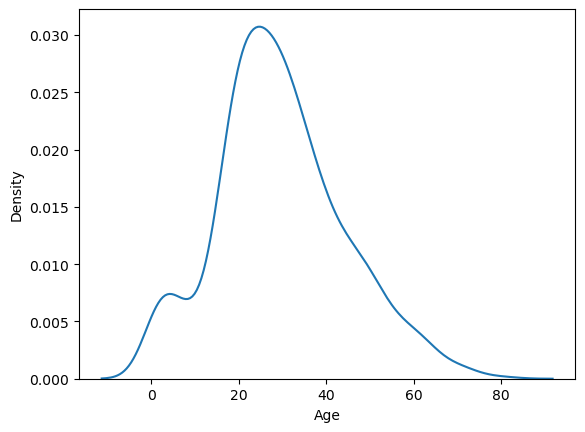

In [10]:
sns.kdeplot(x = 'Age', data = df)
plt.show()

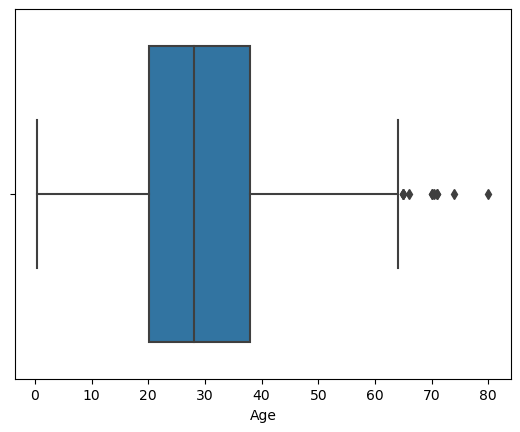

In [11]:
sns.boxplot(x = 'Age', data = df)
plt.show()

In [12]:
print(f'Mean : {df["Age"].mean()}')
print(f'Median : {df["Age"].median()}')

Mean : 29.69911764705882
Median : 28.0


In [13]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Here as you can see that the there are 77% of the data whcih is null and aditionally there is not a valid column so deciding to drop the column of cabin

In [15]:
df.drop(columns=['Cabin'], inplace=True)

Dropping the Null Values / Dropping the null values of the specific column

In [16]:
df.dropna(inplace=True)

In [17]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Finding the duplicated Rows and dropping it 

In [18]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 889, dtype: bool

In [19]:
df.duplicated().sum()

0

Dropping the duplicated rows

In [20]:
df.drop_duplicates(inplace=True)

Converting the Data type of a particular column

In [21]:
df.Age = df['Age'].astype(int)

In [22]:
# df['JoinDate'] = pd.to_datetime(df['JoinDate'])

Creating the bins of the age and divinding it into the Age Group (Bussiness Logic)

In [23]:
from cProfile import label


df['Age Group'] = pd.cut(
    df['Age'],
    bins = [0, 12, 20, 40, 60, 100],
    labels = ['Child', 'Teen', 'Adult', 'Middle Age', 'Senior']
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,Adult


In [24]:
df[df['Age Group'] == 'Senior']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age Group
33,34,0,2,"Wheadon, Mr. Edward H",male,66,0,0,C.A. 24579,10.5000,S,Senior
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65,0,1,113509,61.9792,C,Senior
96,97,0,1,"Goldschmidt, Mr. George B",male,71,0,0,PC 17754,34.6542,C,Senior
116,117,0,3,"Connors, Mr. Patrick",male,70,0,0,370369,7.7500,Q,Senior
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61,0,0,111240,33.5000,S,Senior
252,253,0,1,"Stead, Mr. William Thomas",male,62,0,0,113514,26.5500,S,Senior
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63,1,0,13502,77.9583,S,Senior
280,281,0,3,"Duane, Mr. Frank",male,65,0,0,336439,7.7500,Q,Senior
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61,0,0,345364,6.2375,S,Senior
438,439,0,1,"Fortune, Mr. Mark",male,64,1,4,19950,263.0000,S,Senior


Dividing the salaries using the quantile cut (Modelling Logic)

In [25]:
df['Income type'] = pd.qcut(
    df['Fare'],
    q = 4,
    labels = ['Low','Medium','High','Very High']
)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age Group,Income type
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,Adult,Very High
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,Adult,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,Adult,Very High
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,Adult,Medium


In [26]:
df['Income type'].value_counts()

Medium       224
Low          223
High         222
Very High    220
Name: Income type, dtype: int64

TO Findout Which are the ouliers ( in this case it the outliers for the Fare)

In [27]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]

outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age Group,Income type
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,Adult,Very High
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19,3,2,19950,263.0000,S,Teen,Very High
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28,1,0,PC 17569,146.5208,C,Adult,Very High
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28,1,0,PC 17604,82.1708,C,Adult,Very High
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49,1,0,PC 17572,76.7292,C,Middle Age,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,28,8,2,CA. 2343,69.5500,S,Adult,Very High
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,28,1,0,17453,89.1042,C,Adult,Very High
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45,1,1,36928,164.8667,S,Middle Age,Very High
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,28,8,2,CA. 2343,69.5500,S,Adult,Very High


In [28]:
outliers[outliers['Fare'] > 500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age Group,Income type
258,259,1,1,"Ward, Miss. Anna",female,35,0,0,PC 17755,512.3292,C,Adult,Very High
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36,0,1,PC 17755,512.3292,C,Adult,Very High
737,738,1,1,"Lesurer, Mr. Gustave J",male,35,0,0,PC 17755,512.3292,C,Adult,Very High


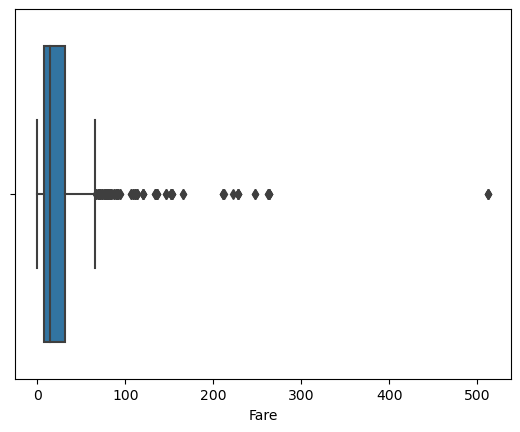

In [29]:
sns.boxplot(x = 'Fare', data = df)
plt.show()

In [30]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]

outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age Group,Income type
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,S,Child,High
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.5500,S,Middle Age,High
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55,0,0,248706,16.0000,S,Middle Age,High
16,17,0,3,"Rice, Master. Eugene",male,2,4,1,382652,29.1250,Q,Child,High
33,34,0,2,"Wheadon, Mr. Edward H",male,66,0,0,C.A. 24579,10.5000,S,Senior,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
824,825,0,3,"Panula, Master. Urho Abraham",male,2,4,1,3101295,39.6875,S,Child,Very High
827,828,1,2,"Mallet, Master. Andre",male,1,0,2,S.C./PARIS 2079,37.0042,C,Child,Very High
831,832,1,2,"Richards, Master. George Sibley",male,0,1,1,29106,18.7500,S,NaN,High
851,852,0,3,"Svensson, Mr. Johan",male,74,0,0,347060,7.7750,S,Senior,Low


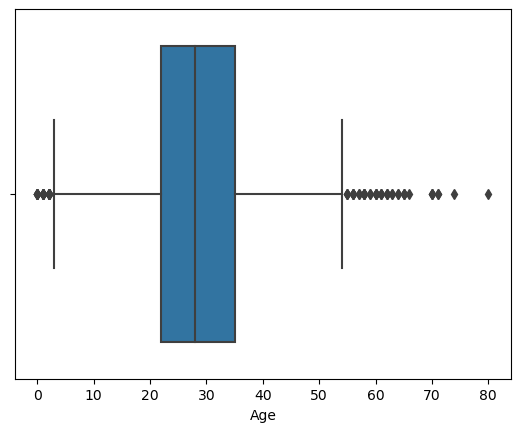

In [31]:
sns.boxplot(x = 'Age', data = df)
plt.show()

In [32]:
# Check more on the Fare of the Outlier paste it in the GPT and get more insights on that 

In [33]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Age Group      7
Income type    0
dtype: int64

In [34]:
df.dropna(inplace=True)

In [35]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Age Group      0
Income type    0
dtype: int64

In [36]:
df.shape

(882, 13)

Feature Scaling of the Dataframe of titanic Dataset

In [37]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,882.000000,882.000000,882.000000,882.000000,882.000000,882.000000,882.000000
mean,445.126984,0.377551,2.311791,29.531746,0.520408,0.375283,32.055687
std,256.763846,0.485049,0.835681,12.778725,1.105210,0.804909,49.716175
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,223.250000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,444.500000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,666.750000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age Group,Income type
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,Adult,Very High
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,Adult,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,Adult,Very High
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,Adult,Medium


In [39]:
# Dropping the unnecessary columns
dfcopy = df.copy()

In [40]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Age Group', 'Income type'],
      dtype='object')

In [41]:
df.drop(columns = ['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Embarked'], inplace=True)

In [42]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Age Group,Income type
0,0,3,male,22,7.2500,Adult,Low
1,1,1,female,38,71.2833,Adult,Very High
2,1,3,female,26,7.9250,Adult,Medium
3,1,1,female,35,53.1000,Adult,Very High
4,0,3,male,35,8.0500,Adult,Medium


In [43]:
df.describe()

,Survived,Pclass,Age,Fare
count,882.000000,882.000000,882.000000,882.000000
mean,0.377551,2.311791,29.531746,32.055687
std,0.485049,0.835681,12.778725,49.716175
min,0.000000,1.000000,1.000000,0.000000
25%,0.000000,2.000000,22.000000,7.895800
50%,0.000000,3.000000,28.000000,14.454200
75%,1.000000,3.000000,35.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


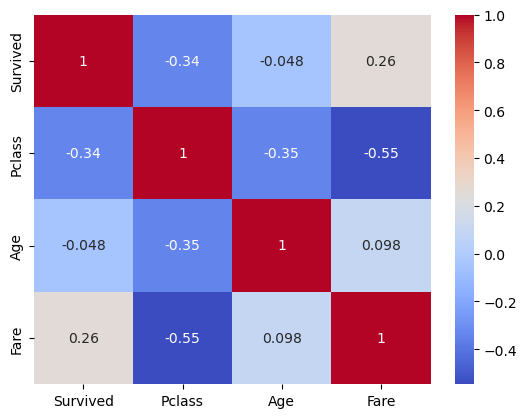

In [44]:
# Getting a heat map of the dataframe
corr = df.corr()
sns.heatmap(corr, annot=True, cmap = 'coolwarm')
plt.show()

In [45]:
df['Sex'].value_counts()

male      572
female    310
Name: Sex, dtype: int64

In [79]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Age Group,Income type
0,0,3,1,22,7.2500,1,1
1,1,1,2,38,71.2833,1,4
2,1,3,2,26,7.9250,1,2
3,1,1,2,35,53.1000,1,4
4,0,3,1,35,8.0500,1,2


Mapping the Age group and Income type And the Sex

In [47]:
df['Age Group'].value_counts()

Adult         562
Middle Age    126
Teen          111
Child          62
Senior         21
Name: Age Group, dtype: int64

In [48]:
df['Age Group'] = df['Age Group'].map(
    {
        'Adult' : 1,
        'Middle Age' : 2,
        'Teen' : 3,
        'Child' : 4,
        'Senior' : 5
    }
)

In [49]:
df['Income type'].value_counts()

Low          223
Medium       223
Very High    219
High         217
Name: Income type, dtype: int64

In [50]:
df['Income type'] = df['Income type'].map(
    {
        'Low' : 1,
        'Medium' : 2,
        'High' : 3,
        'Very High' : 4
    }
)

In [51]:
df['Sex'].value_counts()

male      572
female    310
Name: Sex, dtype: int64

In [52]:
df['Sex'] = df['Sex'].map(
    {
        'male' : 1,
        'female' : 2
    }
)

In [53]:
df.isnull().sum()

Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
Age Group      0
Income type    0
dtype: int64

Splitting the Data into X and y

In [54]:
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'Income type', 'Age Group']]
y = df['Survived']

In [75]:
df[['Age']]

,Age
0,22
1,38
2,26
3,35
4,35
...,...
886,27
887,19
888,28
889,26


In [78]:
df[['Fare']]

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


Train Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=100)

Model 1: Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Accuracy Score: {accuracy_score(y_test, y_pred)}')

Accuracy Score: 0.7344632768361582


Model 2: Random Forest (Better Performance)

In [ ]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Accuracy Score : {accuracy_score(y_test, y_pred)}')

Accuracy Score : 0.7796610169491526


Feature Importances : The importance score is essentially a measure of how much each feature contributed to improving those splits.

In [69]:
importances = model.feature_importances_

feature_names = X.columns

for name, val in zip(feature_names, importances):
    print(name, val)

Pclass 0.1043105969626983
Sex 0.2787348556162914
Age 0.23839747208548737
Fare 0.29530148945533974
Income type 0.04433608783989666
Age Group 0.03891949804028658


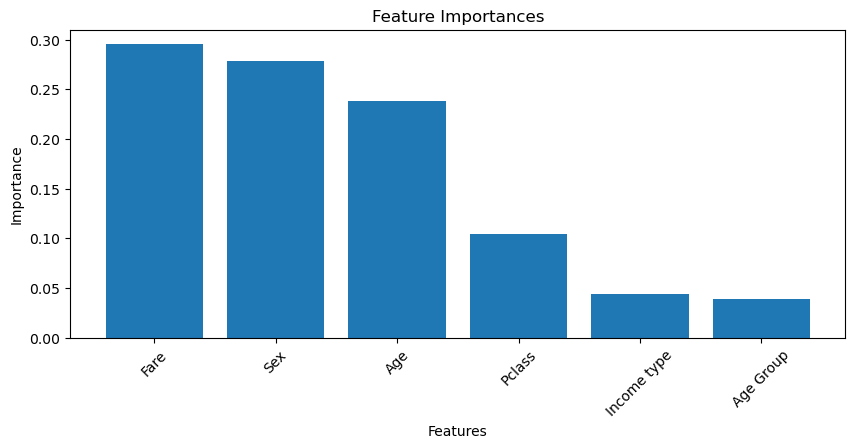

In [70]:
# Create a DataFrame for easy sorting and plotting
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,4))
plt.bar(feat_importances['Feature'], feat_importances['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [71]:
df['Survived'].value_counts(normalize = True)

0    0.622449
1    0.377551
Name: Survived, dtype: float64

In [61]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

print(f'F1 Score : {f1_score(y_test, y_pred)}')
print(f'Precision : {precision_score(y_test, y_pred)}')
print(f'Recall : {recall_score(y_test, y_pred)}')
print(f'ROC Score : {roc_auc_score(y_test, y_pred)}')

F1 Score : 0.706766917293233
Precision : 0.734375
Recall : 0.6811594202898551
ROC Score : 0.7618760064412238


In [62]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[91 17]
 [22 47]]


In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       108
           1       0.73      0.68      0.71        69

    accuracy                           0.78       177
   macro avg       0.77      0.76      0.77       177
weighted avg       0.78      0.78      0.78       177



Learning of the Oversampling and Undersampling for Imbalanced Data (Here the data that we reffered to is the Target variable mostly in the Imbalanced data is of the target variable)

In [82]:
df['Survived'].value_counts(normalize = True)

0    0.622449
1    0.377551
Name: Survived, dtype: float64

In [83]:
df['Survived'].value_counts()

0    549
1    333
Name: Survived, dtype: int64

Apply SMOTE Only on the Training Data 

In [ ]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# # 3. Train model
# model.fit(X_train_resampled, y_train_resampled)

Understanding More on the Undersampling and oversampling 

📊 1. BEFORE Sampling (Original Imbalance)

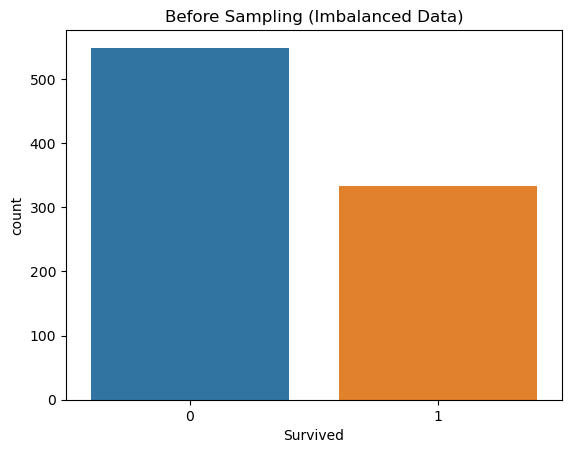

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.title("Before Sampling (Imbalanced Data)")
plt.show()

📊 2. AFTER UNDER-SAMPLING

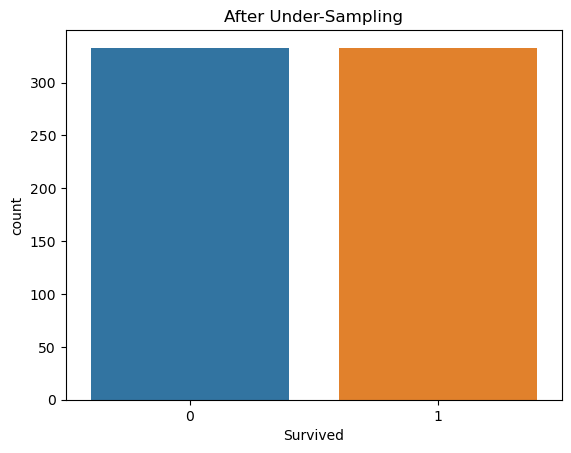

In [89]:
from sklearn.utils import resample

# Separate classes
df_majority = df[df['Survived'] == 0]
df_minority = df[df['Survived'] == 1]

# Downsample
df_majority_downsampled = resample(df_majority,
                                  replace=False,
                                  n_samples=len(df_minority),
                                  random_state=42)

df_under = pd.concat([df_majority_downsampled, df_minority])

# Plot
sns.countplot(x='Survived', data=df_under)
plt.title("After Under-Sampling")
plt.show()

📊 3. AFTER OVER-SAMPLING (Simple)

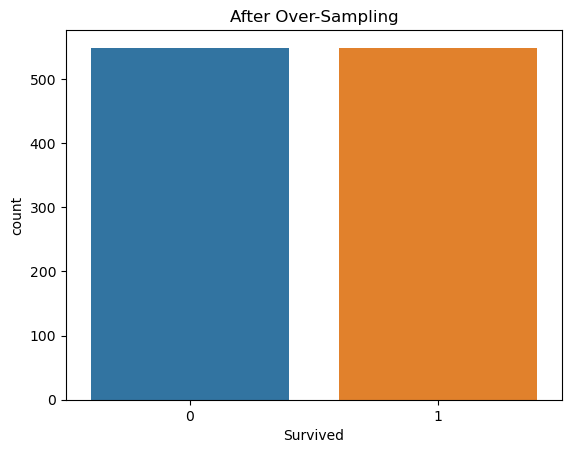

In [91]:
# Upsample minority
df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

df_over = pd.concat([df_majority, df_minority_upsampled])

# Plot
sns.countplot(x='Survived', data=df_over)
plt.title("After Over-Sampling")
plt.show()

📊 4. AFTER SMOTE (BEST VISUAL)

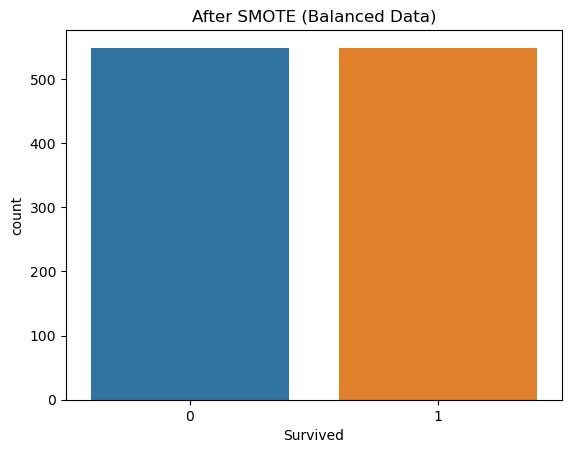

In [92]:
from imblearn.over_sampling import SMOTE

X = df.drop('Survived', axis=1)
y = df['Survived']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Convert to DataFrame for plotting
df_smote = X_res.copy()
df_smote['Survived'] = y_res

# Plot
sns.countplot(x='Survived', data=df_smote)
plt.title("After SMOTE (Balanced Data)")
plt.show()